In [33]:
####################################
#ENVIRONMENT SETUP

In [34]:
#LIBRARIES

#system
import os
import sys

#math and array operations
import numpy as np
import math
import pandas as pd

#data classes
import xarray as xr
import pickle

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#loading bar
from tqdm import tqdm

#datetime
from datetime import datetime

In [35]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [36]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "Observation_Data")
dataType = "RadarComparison"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER/RadarComparison



In [37]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [38]:
spinup_hours = "0"

RunType = ("TRACER","WET","NSSL",spinup_hours)
# RunType = ("TRACER","DRY","NSSL",spinup_hours)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

RunType = ("TRACER","WET","TEMPO",spinup_hours)
# RunType = ("TRACER","DRY","TEMPO",spinup_hours)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-07-01 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:193
 # Diag Files:   193
 # Time Steps:   193
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs
 Static File:    TRACER_regional5250_scaled3_

In [39]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_MRMS_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [40]:
#Importing ERA5 Data Loading Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","ERA5_Data"))
from CLASSES_ERA5DataLoading import ERA5DataLoading_Class,ERA5DataLoading_Class_gdex

In [41]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSaving import DataSaving_Class

In [42]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Plotting import ContourPlotting_Class

In [43]:
####################################
#DATA LOADING

In [44]:
t=92
radarNSSL = ModelData_NSSL.GetDataTimestep_diag(t=t)["refl10cm"]
radarNSSL = radarNSSL.where(radarNSSL > 0)
radarTEMPO = ModelData_TEMPO.GetDataTimestep_diag(t=t)["refl10cm"]
radarTEMPO = radarNSSL.where(radarTEMPO > 0)

Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_23.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_23.00.00.latlon.nc


In [45]:
####################################
#CALCULATION FUNCTIONS

In [54]:
# def CreateCFAD_original(radarData, bin_levels = (-35, 85), minValue=0):
#     """
#     Create a CFAD from a 3D reflectivity field (Z, Y, X).
#     """

#     bins = np.arange(bin_levels[0], bin_levels[1]+2, 1)  # DBZ bins

#     nZ = radarData.shape[0]
#     cfad = np.zeros((nZ, len(bins)-1))

#     radarData = radarData.where(radarData>=minValue)
    
#     for k in range(nZ):

#         # Get a single z level
#         layer = radarData.isel(nVertLevels=k).values.flatten()

#         # histogram
#         hist, _ = np.histogram(layer, bins=bins)

#         # normalize by total at this altitude
#         cfad[k, :] = hist / hist.sum()

#     bin_centers = 0.5 * (bins[:-1] + bins[1:])
#     return cfad, bin_centers

def CreateCFAD(radarData, bin_levels=(-35, 85), minValue=0,
               convertToLinear=False):
    """
    Create a CFAD from a 3D reflectivity field (Z, Y, X).

    If convertToLinear=True:
        radarData is assumed to be in dBZ and converted to linear Z.
        Linear-Z bins are generated accordingly.
    """

    import numpy as np

    # --- Convert dBZ → Z BEFORE histogramming -------------------------------
    if convertToLinear:
        radarData = 10 ** (radarData / 10)
        # example linear bins (log-spaced; change if needed)
        bins = np.logspace(-3, 6, 200)
    else:
        # dBZ bins (your original)
        bins = np.arange(bin_levels[0], bin_levels[1] + 2, 1)

    # --- Allocate CFAD array -------------------------------------------------
    nZ = radarData.shape[0]
    cfad = np.zeros((nZ, len(bins)-1))

    # --- Apply threshold -----------------------------------------------------
    radarData = radarData.where(radarData >= minValue)

    # --- Build CFAD ----------------------------------------------------------
    for k in range(nZ):
        layer = radarData.isel(nVertLevels=k).values.flatten()
        hist, _ = np.histogram(layer, bins=bins)

        if hist.sum() > 0:
            cfad[k, :] = hist / hist.sum()

    # --- Bin centers ---------------------------------------------------------
    binCenters = 0.5 * (bins[:-1] + bins[1:])
    return cfad, binCenters


In [55]:
filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/TRACER/WET/MPAS-Model_8.3.1_56nz/zeta_30km_57levels.txt"
zlevels = np.loadtxt(filePath)/1e3

In [56]:
####################################
#PLOTTING FUNCTIONS

In [57]:
def GetCFADColormap():
    colors = [
        "#FFFF00",  # yellow
        "#4CAF50",  # slightly darker green
        "#8BC34A",  # slightly lighter green
        "#006400",  # dark green
        "#0000FF",  # blue
        "#800080",  # purple
        "#FF0000"   # red
    ]
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    
    custom_cmap = ListedColormap(colors, name="custom_cmap")
    return custom_cmap
custom_cmap = GetCFADColormap()

In [58]:
def PlotCFAD(cmap='turbo'):
    
    # --- Compute both CFADs ---
    cfad_NSSL, bins = CreateCFAD(radarNSSL, bin_levels=(-35,40), minValue=0)
    cfad_TEMPO, _   = CreateCFAD(radarTEMPO, bin_levels=(-35,40), minValue=0)
    
    # --- Compute common color limits across both ---
    vmin = np.nanmin([cfad_NSSL, cfad_TEMPO])
    vmax = np.nanmax([cfad_NSSL, cfad_TEMPO])
    
    # --- Setup GridSpec ---
    fig = plt.figure(figsize=(15, 6))
    gs = gridspec.GridSpec(
        nrows=1, 
        ncols=3,           # 2 CFADs + 1 colorbar
        width_ratios=[1, 1, 0.05],   # thin colorbar column
        wspace=0.1
    )
    
    # --- Axes for the CFADs ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])
    
    z = zlevels[:-1]
    
    # --- NSSL ---
    cf1 = ax1.contourf(
        bins, z, cfad_NSSL,
        cmap=cmap,
        levels=100,
        vmin=vmin, vmax=vmax
    )
    ax1.set_title("CFAD – NSSL")
    ax1.set_xlabel("Reflectivity (dBZ)")
    ax1.set_ylabel("Altitude (km or levels)")
    
    # --- TEMPO ---
    cf2 = ax2.contourf(
        bins, z, cfad_TEMPO,
        cmap=cmap,
        levels=100,
        vmin=vmin, vmax=vmax
    )
    ax2.set_title("CFAD – TEMPO")
    ax2.set_xlabel("Reflectivity (dBZ)")
    
    # --- Shared vertical colorbar ---
    cbar = fig.colorbar(cf2, cax=cax)
    cbar.set_label("Normalized Frequency")
    
    # --- Match altitude limits ---
    ax1.set_xlim(left=0, right=40)
    ax2.set_xlim(left=0, right=40)
    ax1.set_ylim(top=15)
    ax2.set_ylim(top=15)

In [59]:
####################################
#PLOTTING

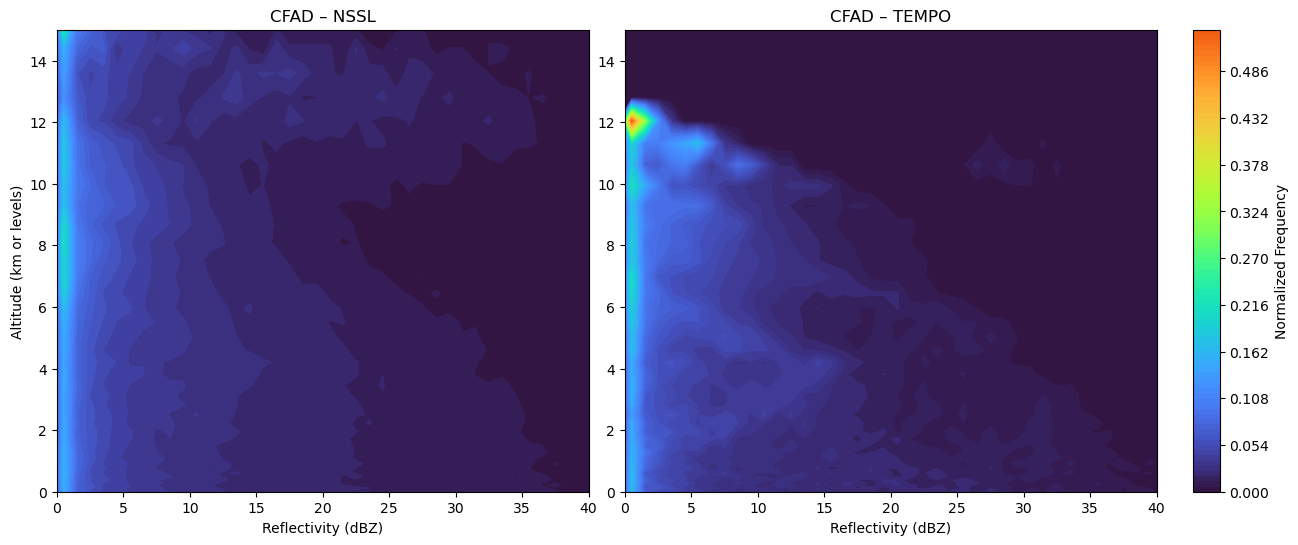

In [60]:
PlotCFAD()